# Predictive Modelling of Proteomics using a Transformer Model

## Task Type and Model Decision
I selected a Transformer model because the multi-head attention can learn different types of relationships between omics data features and capturing various correlations that might exist. The self-attention mechanism allows the model to identify important feature interactions, which I think are important in multi-omics data integration. While VAEs would also be suitable, particularly for handling noise and missing values, the potential complex interactions between omics data features made Transformers my preferred choice.

## Data
The aim is to use multiple input omics datasets to predict proteomics data. Input omics data was selected by iteratively testing combinations to determine which best predicted proteomics. This indicated that transcriptomics data only as the optimal input combination for proteomics prediction.

## Plan
The approach follows a systematic comparison between a baseline MLP model and the Transformer architecture:

#### In EMBL_transformer_explore.ipynb
1. [Inspect data](#inspect-data);
2. [Create a simple MLP model](#baseline-mlp) as a baseline;
3. [Develop Transformer models](#transformer-models) with different fusion strategies and activation functions;
4. [Perform hyperparameter tuning](#hyperparameter-tuning);
5. [Conduct progressive input omics selection](#omics-selection);
6. [Create comprehensive loop](#evaluation-loop) to iterate through steps 3-5, obtaining metrics to determine the best Transformer model for comparison with the baseline MLP;

#### In EMBL_transformer_best_model.ipynb
7. [Select best-performing model](#best-performing);
8. [Analyse best-predicted proteomic features](#feature-analysis);


## Results
- The [baseline MLP model](#results-MLP) performed quite well already, with an R^2 ~0.83, an RMSE ~0.69, and prediction errors that are roughly Normally distributed.
- The best [Transformer model](#results-transformer) demonstrated that using transcriptomics data only as input omics data performed best, with R^2 ~0.83. However, rerunning the algorithm shows some variability in the best performing hyperparameters, such as fusion method selected. In addition, the Transformer model does not significantly outperform the baseline MLP model. Moving forward, cross-validation and improved data handling (e.g. outlier handling) would be worth exploring. 
- The results of the [feature analysis](#results-feature-analysis) showed significant correlation values >0.5 between the predicted and actual values. However, the R^2 values are low, indicating that while the general trends in protein expression are captured, the model does not accurately predict the exact values. 

## Future Work
Given more time, I would implement:

1. Cross-validation for more robust model evaluation;
2. Enhanced data handling, particularly for outliers. Despite the task stating the data was "processed and cleaned, so you can use them directly" I encountered outliers that might affect results. Going forward, I would address these outliers prior to modelling;
3. Development of ensemble methods to potentially improve prediction accuracy.



In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# for using VSCode
import sys
from pathlib import Path

# Add the parent directory of transformer_multiomics to sys.path
sys.path.append(str(Path.cwd().parent))

In [3]:
from transformer_multiomics.config import DATA_PATH, MODEL_PATH, RESULT_PATH
from transformer_multiomics.data.data_loader import ensure_directories_exist, load_datasets
from transformer_multiomics.data.data_preparation import prepare_data_loaders
from transformer_multiomics.models.mlp import MultiOmicsMLP
from transformer_multiomics.training.evaluater import (
    analyse_feature_level_performance,
    evaluate_model,
    summarise_results,
)
from transformer_multiomics.training.optimizing import progressive_omics_selection
from transformer_multiomics.training.trainer import train_model
from transformer_multiomics.utils.plots import plot_error_distribution, plot_loss_curves

In [4]:
# CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# Ensure directories exist
ensure_directories_exist(MODEL_PATH, RESULT_PATH, DATA_PATH)

# Load datasets
datasets = load_datasets()
print("Available datasets:", datasets.keys())

Directory exists: /home/jantine/Projects/transformer_multiomics/models
Directory exists: /home/jantine/Projects/transformer_multiomics/results
Directory exists: /home/jantine/Projects/transformer_multiomics/datasets
Available datasets: dict_keys(['methylation', 'metabolomics', 'proteomics', 'transcriptomics', 'cnv'])


# MLP Base Model <a id="baseline-mlp"></a> 
The idea is to start with a simple MLP base model with a few hidden layers to serve as a benchmark for the Transformer. This base model will also only use one type of input omics data, i.e. transcriptomics, to predict the proteomics data.

In [6]:
input_datasets = ["transcriptomics", "methylation", "metabolomics", "cnv"]
target_dataset = "proteomics"

train_loader, val_loader, test_loader, input_dims_dict, output_dim = prepare_data_loaders(
    omics_set=input_datasets, datasets=datasets, target_dataset=target_dataset, batch_size=32, test_size=0.2
)

In [7]:
# Initialize model with multi-omics input dims
mlp_model = MultiOmicsMLP(input_dims_dict=input_dims_dict, output_dim=output_dim, hidden_dims=[256, 128, 64]).to(device)

# Loss function and optimiser
mlp_criterion = nn.MSELoss()
learning_rate = 0.001
weight_decay = 0
mlp_optimiser = optim.Adam(mlp_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Early stopping setup
patience = 15
epochs = 100

mlp_model = MultiOmicsMLP(input_dims_dict=input_dims_dict, output_dim=output_dim, hidden_dims=[256, 128, 64]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=0)

trained_model, train_losses, test_losses, best_loss, early_stop_epoch, _ = train_model(
    model=mlp_model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=epochs,
    patience=patience,
    model_name="multiomics_mlp",
    save_path=MODEL_PATH,
    return_attention_weights=False,
)

Starting training for multiomics_mlp...


Epoch 1/100 | Train Loss: 28.5345 | Test Loss: 17.9958 | Early Stopping: 0/15


Epoch 11/100 | Train Loss: 1.6080 | Test Loss: 1.3440 | Early Stopping: 0/15


Epoch 21/100 | Train Loss: 0.4674 | Test Loss: 0.4967 | Early Stopping: 0/15


Epoch 31/100 | Train Loss: 0.4482 | Test Loss: 0.4819 | Early Stopping: 0/15


...

Epoch 61/100 | Train Loss: 0.4347 | Test Loss: 0.4752 | Early Stopping: 0/15


Epoch 71/100 | Train Loss: 0.4325 | Test Loss: 0.4774 | Early Stopping: 1/15


Epoch 81/100 | Train Loss: 0.4320 | Test Loss: 0.4787 | Early Stopping: 1/15


Epoch 91/100 | Train Loss: 0.4317 | Test Loss: 0.4902 | Early Stopping: 2/15


Epoch 100/100 | Train Loss: 0.4337 | Test Loss: 0.4990 | Early Stopping: 11/15
Best model saved to /home/jantine/Projects/transformer_multiomics/models/best_multiomics_mlp_model.pt


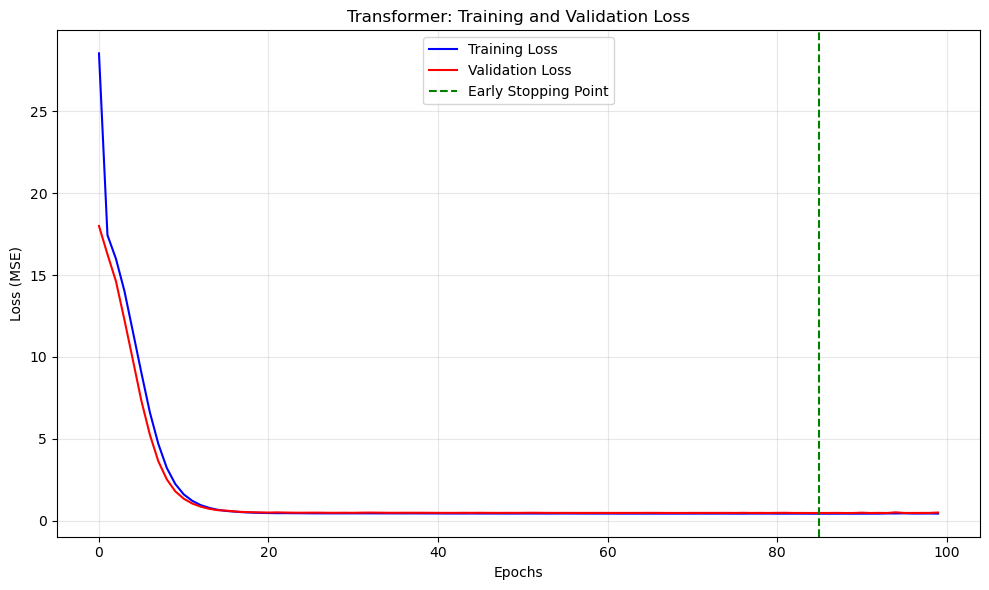

In [8]:
# Plot training and validation loss curves
early_stopping_epoch = len(test_losses) - patience
plot_loss_curves(
    train_losses,
    test_losses,
    early_stopping_epoch=early_stopping_epoch,
    title="Transformer: Training and Validation Loss",
)

In [9]:
# Evaluate model performance
metrics_mlp = evaluate_model(mlp_model, test_loader, device, is_transformer=False, model_name="MLP")

Evaluating MLP: 100%|██████████| 2/2 [00:00<00:00, 323.26it/s]

MLP Performance:
R-squared (R²): 0.8324
Root Mean Squared Error (RMSE): 0.7064
Mean Absolute Error (MAE): 0.5176
Explained Variance Score: 0.8403


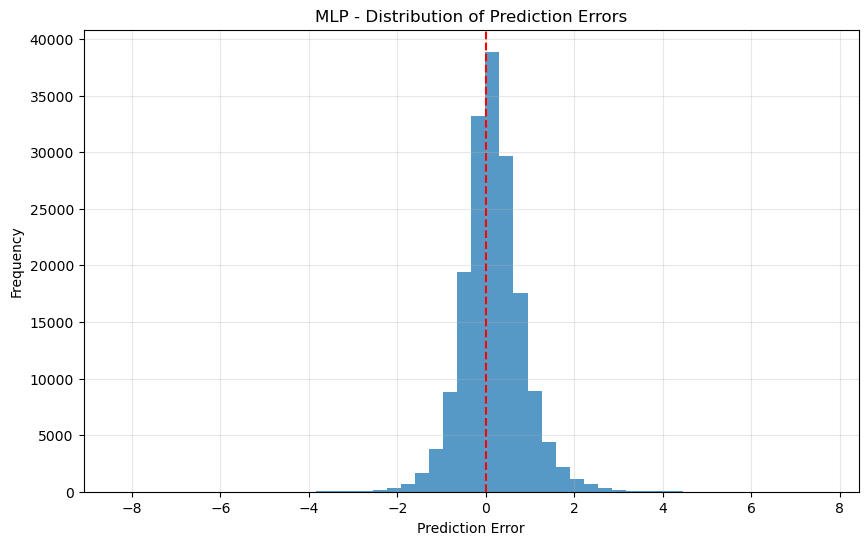

In [10]:
# Plot error distribution
all_predictions = metrics_mlp["predictions"]
all_targets = metrics_mlp["targets"]

plot_error_distribution(all_predictions, all_targets, model_name="MLP")

# Baseline MLP Results <a id="results-MLP"></a>

The MLP is performing quite well already, with R^2 of ~0.83 and the error distribution normally distributed. The errors look Normally distributed, so the MLP is already performing well without systematically overestimating/underestimating the target values. 

# Transformer <a id="transformer-models"></a> 

This part is the development of the Transformer model. The Transformer model is designed so that it can be used to iteratively scan through different combinations of input omics data, fusion strategies, activation function (only ReLU and GeLU, as I'm working with PyTorch), and for hyperparameter optimisation.

## Hyperparameter Tuning <a id="hyperparameter-tuning"></a> 

[I 2025-07-16 17:53:59,586] A new study created in memory with name: no-name-484c3817-5fe8-422c-be34-1990f1dccf54



Optimising hyperparameters for omics set: ['transcriptomics']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 17:54:03,109] Trial 0 finished with value: 15.884435653686523 and parameters: {'num_heads': 4, 'num_layers': 2, 'hidden_dim': 512, 'dropout_rate': 0.5, 'learning_rate': 1.058935007589308e-05, 'weight_decay': 1.83971865584244e-05, 'fusion_method': 'gated', 'activation_function': 'gelu'}. Best is trial 0 with value: 15.884435653686523.
[I 2025-07-16 17:54:05,849] Trial 1 finished with value: 15.735199928283691 and parameters: {'num_heads': 16, 'num_layers': 6, 'hidden_dim': 512, 'dropout_rate': 0.5, 'learning_rate': 1.1338073336638703e-05, 'weight_decay': 1.622435509326744e-06, 'fusion_method': 'gated', 'activation_function': 'gelu'}. Best is trial 1 with value: 15.735199928283691.
[I 2025-07-16 17:54:07,903] Trial 2 fini


Best hyperparameters:
  num_heads: 8
  num_layers: 3
  hidden_dim: 448
  dropout_rate: 0.2
  learning_rate: 0.0009466088146129618
  weight_decay: 6.365010448085541e-06
  fusion_method: hierarchical
  activation_function: gelu

Best validation loss: 0.379887

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics']
Starting training for best_model_transcriptomics...


Epoch 1/50 | Train Loss: 16.0907 | Test Loss: 12.9108 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5940 | Test Loss: 0.4660 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4761 | Test Loss: 0.3820 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4805 | Test Loss: 0.3813 | Early Stopping: 0/10


Epoch 41/50 | Train Loss: 0.4788 | Test Loss: 0.3810 | Early Stopping: 7/10



Early stopping at epoch 44


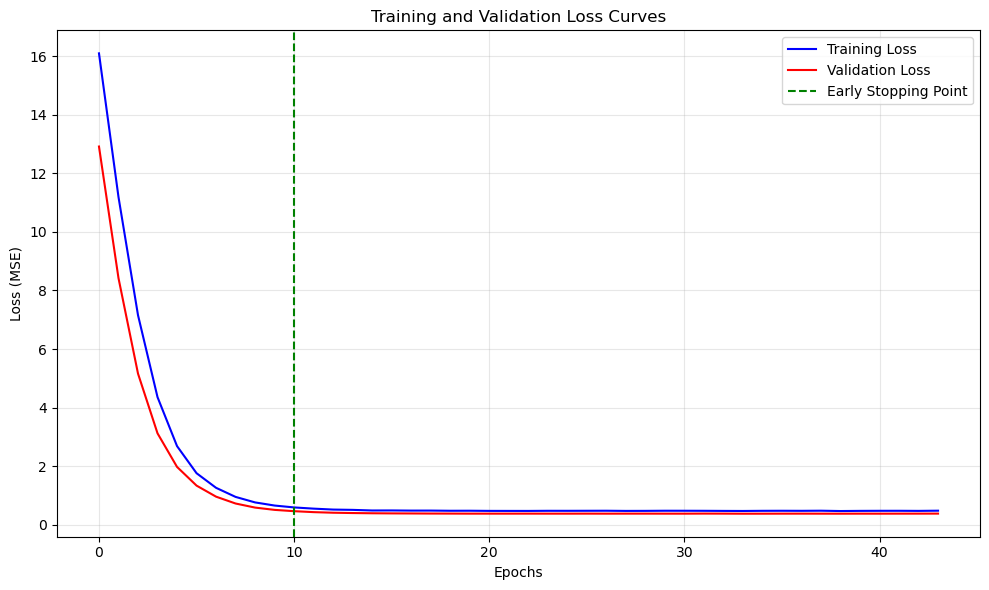


Baseline with ['transcriptomics']: R² = 0.8376


,Step,Current Set,R²,RMSE
0,0,transcriptomics,0.837642,0.695154


[I 2025-07-16 17:55:04,360] A new study created in memory with name: no-name-02ae2274-de42-484e-8b3e-f3dfb1b9778d



Testing omics set: ['transcriptomics', 'methylation']

Optimising hyperparameters for omics set: ['transcriptomics', 'methylation']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 17:55:08,561] Trial 0 finished with value: 0.3810562491416931 and parameters: {'num_heads': 16, 'num_layers': 2, 'hidden_dim': 512, 'dropout_rate': 0.5, 'learning_rate': 0.0005433374721808753, 'weight_decay': 0.0002626628245709175, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 0 with value: 0.3810562491416931.
[I 2025-07-16 17:55:12,186] Trial 1 finished with value: 3.630013942718506 and parameters: {'num_heads': 16, 'num_layers': 3, 'hidden_dim': 384, 'dropout_rate': 0.2, 'learning_rate': 0.00014922613441461136, 'weight_decay': 2.7306829901884504e-05, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 0 with value: 0.3810562491416931.
[I 2025-07-16 17:55:18,461] Tria

...

Epoch 11/50 | Train Loss: 0.5612 | Test Loss: 0.4384 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4829 | Test Loss: 0.3823 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4836 | Test Loss: 0.3822 | Early Stopping: 2/10


Epoch 41/50 | Train Loss: 0.4809 | Test Loss: 0.3818 | Early Stopping: 2/10


Epoch 50/50 | Train Loss: 0.4778 | Test Loss: 0.3839 | Early Stopping: 2/10


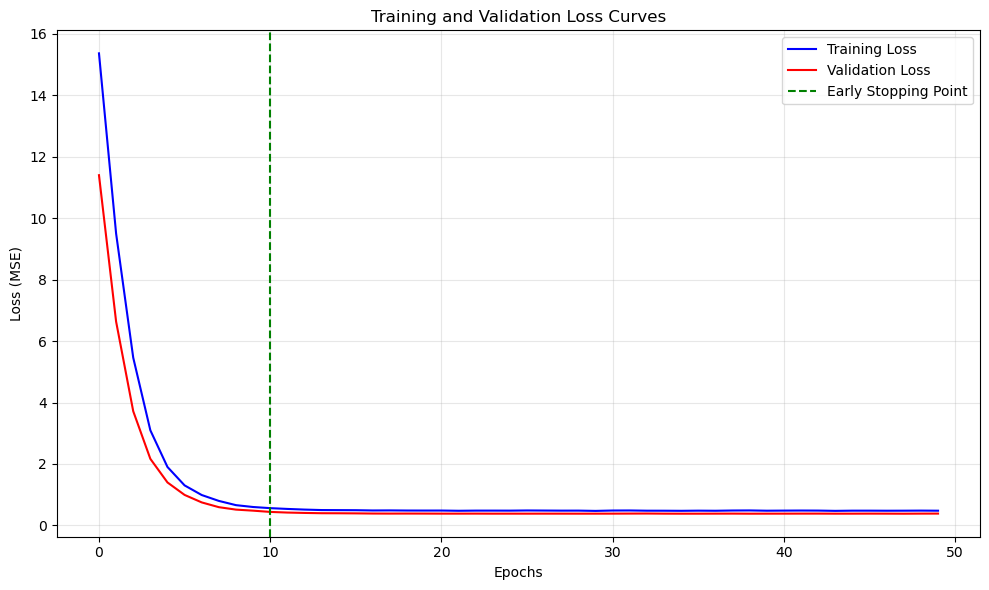

All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Adding methylation → R² = 0.8378 (Δ = +0.0002)

Testing omics set: ['transcriptomics', 'metabolomics']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics']


[I 2025-07-16 17:56:43,290] A new study created in memory with name: no-name-86bee744-d1b8-4150-ad33-6ccc8940cb2d
/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 17:56:46,613] Trial 0 finished with value: 10.495950698852539 and parameters: {'num_heads': 8, 'num_layers': 5, 'hidden_dim': 384, 'dropout_rate': 0.1, 'learning_rate': 5.426528473651897e-05, 'weight_decay': 0.0007620932179170534, 'fusion_method': 'weighted', 'activation_function': 'relu'}. Best is trial 0 with value: 10.495950698852539.
[I 2025-07-16 17:56:50,526] Trial 1 finished with value: 7.238323211669922 and parameters: {'num_heads': 8, 'num_layers': 2, 'hidden_dim': 512, 'dropout_rate': 0.4, 'learning_rate': 6.529068748525775e-05, 'weight_decay': 0.00028658907624847413, 'fusion_method': 'gated', 'act


Best hyperparameters:
  num_heads: 4
  num_layers: 3
  hidden_dim: 512
  dropout_rate: 0.0
  learning_rate: 0.0008928636696128863
  weight_decay: 7.60656266460708e-05
  fusion_method: weighted
  activation_function: gelu

Best validation loss: 0.380017

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics']
Starting training for best_model_transcriptomics_metabolomics...


Epoch 1/50 | Train Loss: 15.9448 | Test Loss: 12.3801 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5347 | Test Loss: 0.4377 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4594 | Test Loss: 0.3817 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4581 | Test Loss: 0.3825 | Early Stopping: 1/10


Epoch 41/50 | Train Loss: 0.4580 | Test Loss: 0.3810 | Early Stopping: 5/10


Epoch 50/50 | Train Loss: 0.4602 | Test Loss: 0.3841 | Early Stopping: 7/10


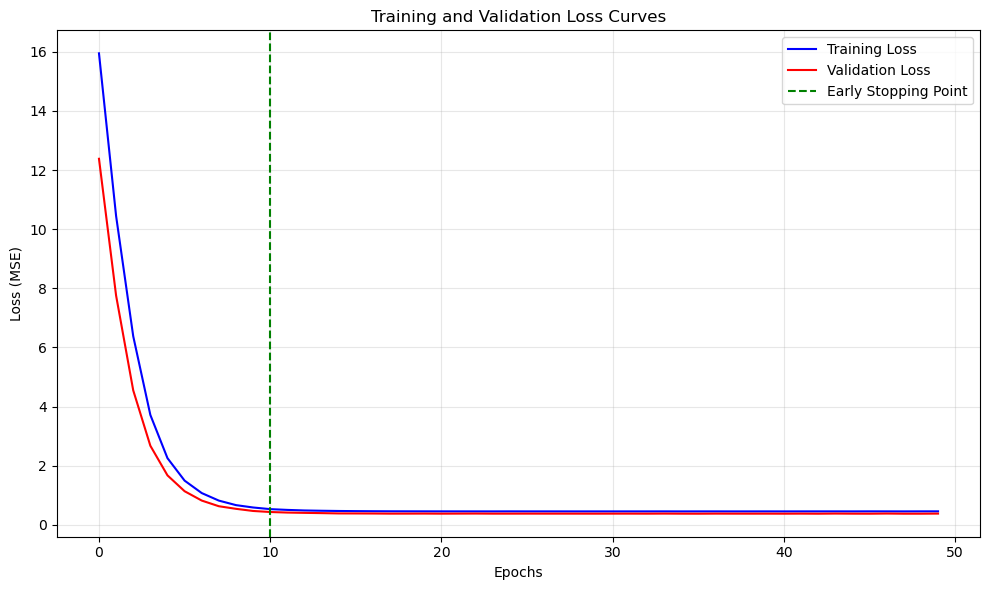

[I 2025-07-16 17:58:01,237] A new study created in memory with name: no-name-dbb67d17-6afe-4fad-bc64-31fe49630611


All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Adding metabolomics → R² = 0.8380 (Δ = +0.0004)

Testing omics set: ['transcriptomics', 'cnv']

Optimising hyperparameters for omics set: ['transcriptomics', 'cnv']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 17:58:04,794] Trial 0 finished with value: 0.38040152192115784 and parameters: {'num_heads': 16, 'num_layers': 3, 'hidden_dim': 384, 'dropout_rate': 0.5, 'learning_rate': 0.0009212175019811023, 'weight_decay': 0.0007155488745925985, 'fusion_method': 'late', 'activation_function': 'relu'}. Best is trial 0 with value: 0.38040152192115784.
[I 2025-07-16 17:58:08,859] Trial 1 finished with value: 0.4397452175617218 and parameters: {'num_heads': 16, 'num_layers': 2, 'hidden_dim': 512, 'dropout_rate': 0.2, 'learning_rate': 0.0002985434232455212, 'weight_decay': 1.0508205904531432e-05, 'fusion_method': 'late', 'activation_function': 'gelu'}. Best is trial 0 with value: 0.38040152192115784.
[I 2025-07-16 17:58:12,407] Trial 2 f


Best hyperparameters:
  num_heads: 16
  num_layers: 3
  hidden_dim: 448
  dropout_rate: 0.30000000000000004
  learning_rate: 0.0008142261728038575
  weight_decay: 8.956232199515392e-06
  fusion_method: late
  activation_function: gelu

Best validation loss: 0.380302

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'cnv']
Starting training for best_model_transcriptomics_cnv...


Epoch 1/50 | Train Loss: 16.3649 | Test Loss: 13.7956 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.6798 | Test Loss: 0.5196 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.4903 | Test Loss: 0.3826 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.4831 | Test Loss: 0.3814 | Early Stopping: 2/10


Epoch 41/50 | Train Loss: 0.4922 | Test Loss: 0.3826 | Early Stopping: 5/10



Early stopping at epoch 46


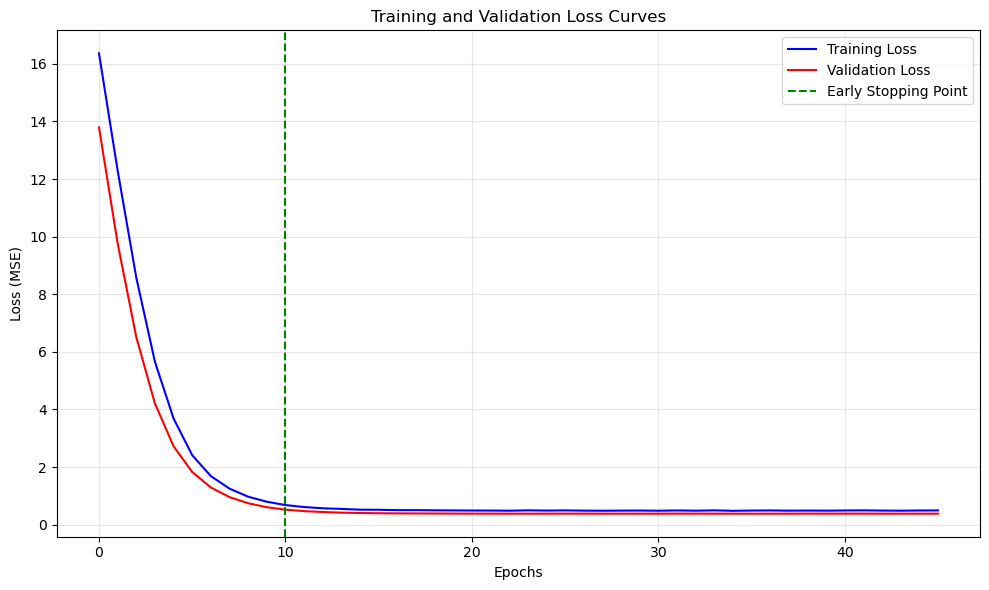

All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics'), ('transcriptomics', 'cnv')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'cnv'), Contains 'Hyperparameters': True
Adding cnv → R² = 0.8369 (Δ = -0.0008)


,Added Omics,Test Set,R²,RMSE,Improvement
1,metabolomics,transcriptomics+metabolomics,0.837992,0.694403,0.000350
0,methylation,transcriptomics+methylation,0.837823,0.694765,0.000181
2,cnv,transcriptomics+cnv,0.836875,0.696793,-0.000767



Added metabolomics. New best set: ['transcriptomics', 'metabolomics'], R²: 0.8380


,Step,Current Set,R²,RMSE,Added
0,0,transcriptomics,0.837642,0.695154,NaN
0,1,transcriptomics+metabolomics,0.837992,0.694403,metabolomics


[I 2025-07-16 17:59:24,286] A new study created in memory with name: no-name-ace761fe-8fe9-4b94-acfc-8e37a5164f57


...

Epoch 11/50 | Train Loss: 0.7222 | Test Loss: 0.5228 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.5359 | Test Loss: 0.3833 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.5300 | Test Loss: 0.3811 | Early Stopping: 0/10


Epoch 41/50 | Train Loss: 0.5194 | Test Loss: 0.3820 | Early Stopping: 2/10



Early stopping at epoch 49


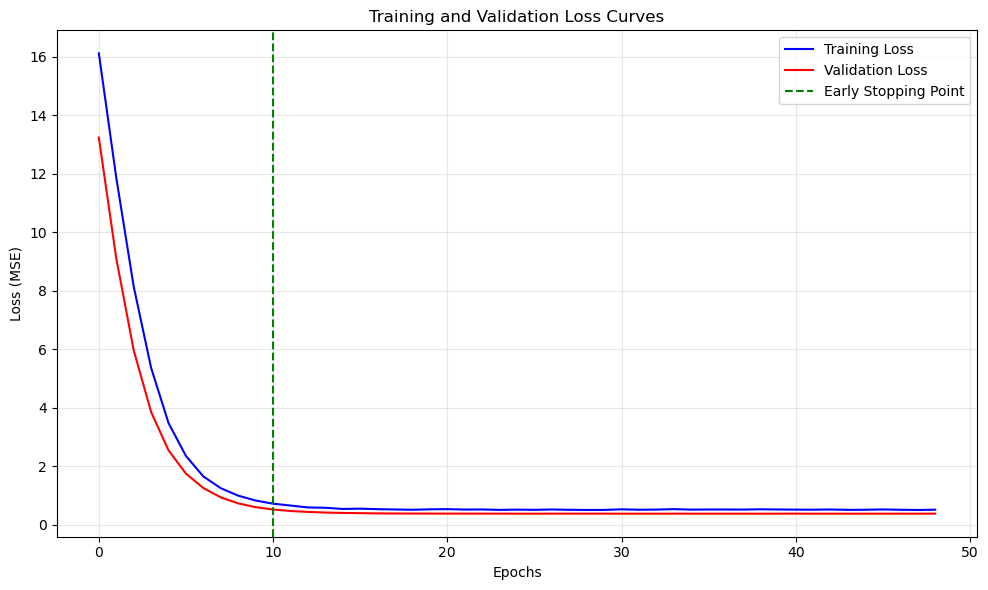

[I 2025-07-16 18:01:10,387] A new study created in memory with name: no-name-6db974a1-5b10-427f-aa95-cb7d8739c887


All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics'), ('transcriptomics', 'cnv'), ('transcriptomics', 'metabolomics', 'methylation')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'cnv'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics', 'methylation'), Contains 'Hyperparameters': True
Adding methylation → R² = 0.8373 (Δ = -0.0007)

Testing omics set: ['transcriptomics', 'metabolomics', 'cnv']

Optimising hyperparameters for omics set: ['transcriptomics', 'metabolomics', 'cnv']


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
[I 2025-07-16 18:01:12,738] Trial 0 finished with value: 14.79312801361084 and parameters: {'num_heads': 16, 'num_layers': 2, 'hidden_dim': 192, 'dropout_rate': 0.4, 'learning_rate': 4.296528492247918e-05, 'weight_decay': 0.00021570151949117957, 'fusion_method': 'cross_attention', 'activation_function': 'relu'}. Best is trial 0 with value: 14.79312801361084.
[I 2025-07-16 18:01:16,104] Trial 1 finished with value: 0.3800734281539917 and parameters: {'num_heads': 8, 'num_layers': 2, 'hidden_dim': 512, 'dropout_rate': 0.5, 'learning_rate': 0.000990380706553759, 'weight_decay': 0.0008735511949993017, 'fusion_method': 'late', 'activation_function': 'gelu'}. Best is trial 1 with value: 0.3800734281539917.
[I 2025-07-16 18:01:20,559] Trial


Best hyperparameters:
  num_heads: 8
  num_layers: 2
  hidden_dim: 512
  dropout_rate: 0.5
  learning_rate: 0.000990380706553759
  weight_decay: 0.0008735511949993017
  fusion_method: late
  activation_function: gelu

Best validation loss: 0.380073

--------------------------------------------------------------------------------
Training final model for omics set: ['transcriptomics', 'metabolomics', 'cnv']
Starting training for best_model_transcriptomics_metabolomics_cnv...


Epoch 1/50 | Train Loss: 16.0070 | Test Loss: 12.6069 | Early Stopping: 0/10


Epoch 11/50 | Train Loss: 0.5999 | Test Loss: 0.4528 | Early Stopping: 0/10


Epoch 21/50 | Train Loss: 0.5141 | Test Loss: 0.3820 | Early Stopping: 0/10


Epoch 31/50 | Train Loss: 0.5048 | Test Loss: 0.3834 | Early Stopping: 2/10



Early stopping at epoch 39


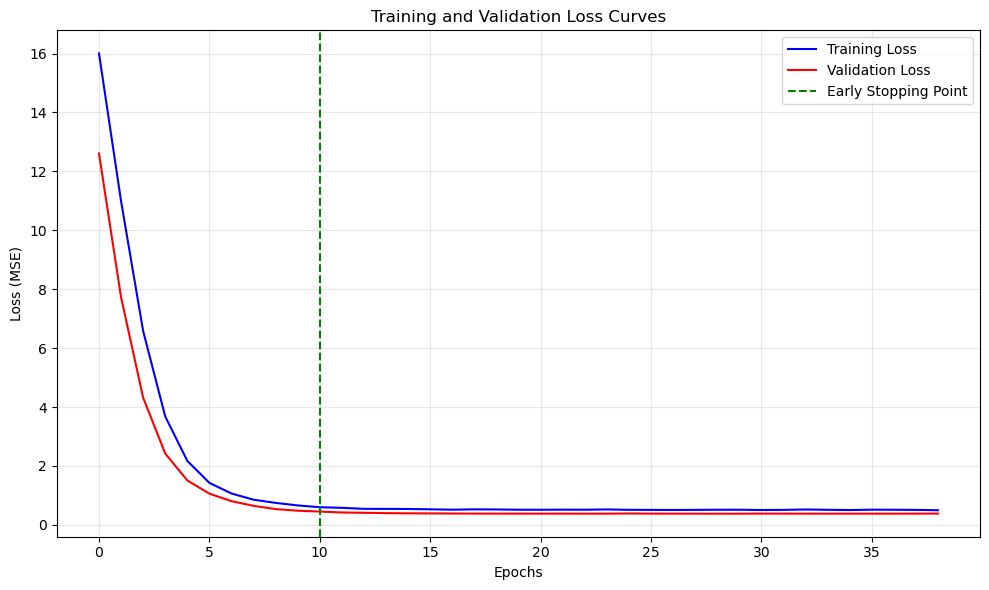

All results keys: dict_keys([('transcriptomics',), ('transcriptomics', 'methylation'), ('transcriptomics', 'metabolomics'), ('transcriptomics', 'cnv'), ('transcriptomics', 'metabolomics', 'methylation'), ('transcriptomics', 'metabolomics', 'cnv')])
Key: ('transcriptomics',), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'cnv'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics', 'methylation'), Contains 'Hyperparameters': True
Key: ('transcriptomics', 'metabolomics', 'cnv'), Contains 'Hyperparameters': True
Adding cnv → R² = 0.8378 (Δ = -0.0002)


,Added Omics,Test Set,R²,RMSE,Improvement
1,cnv,transcriptomics+metabolomics+cnv,0.837752,0.694918,-0.000240
0,methylation,transcriptomics+metabolomics+methylation,0.837269,0.695951,-0.000723



No further improvement. Best set: ['transcriptomics', 'metabolomics'], R²: 0.8380


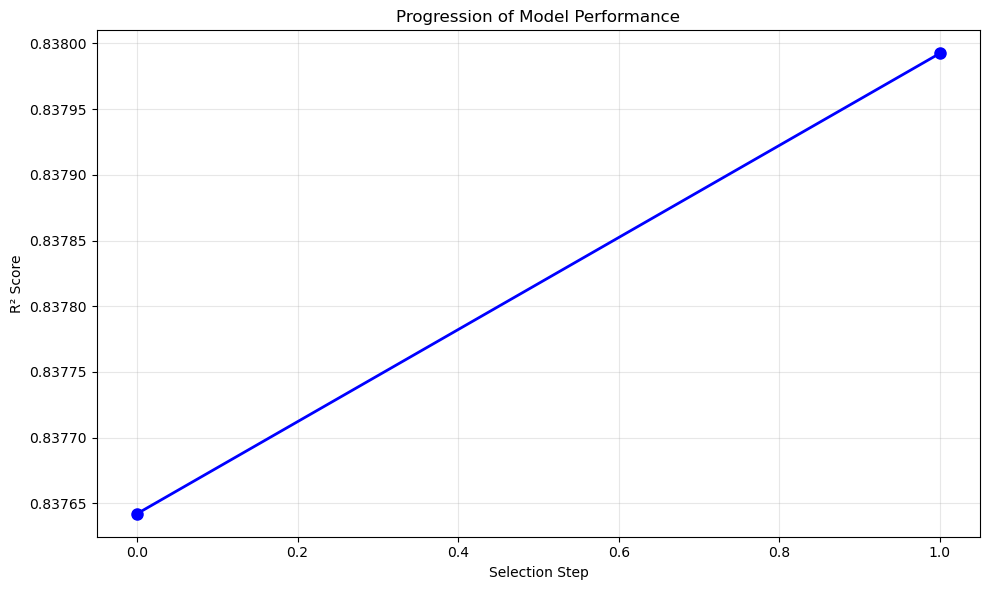



===== SUMMARY OF ALL COMBINATIONS =====
Omics Set                      R²         RMSE       MAE        EVS        Fusion          Activation
------------------------------------------------------------------------------------------
transcriptomics+metabolomics   0.8380     0.6944     0.5065     0.8380     weighted        gelu      
transcriptomics+methylation    0.8378     0.6948     0.5060     0.8379     hierarchical    relu      
transcriptomics+metabolomics+cnv 0.8378     0.6949     0.5069     0.8378     late            gelu      
transcriptomics                0.8376     0.6952     0.5059     0.8379     hierarchical    gelu      
transcriptomics+metabolomics+methylation 0.8373     0.6960     0.5059     0.8379     hierarchical    relu      
transcriptomics+cnv            0.8369     0.6968     0.5062     0.8377     late            gelu      


<Figure size 1200x800 with 0 Axes>

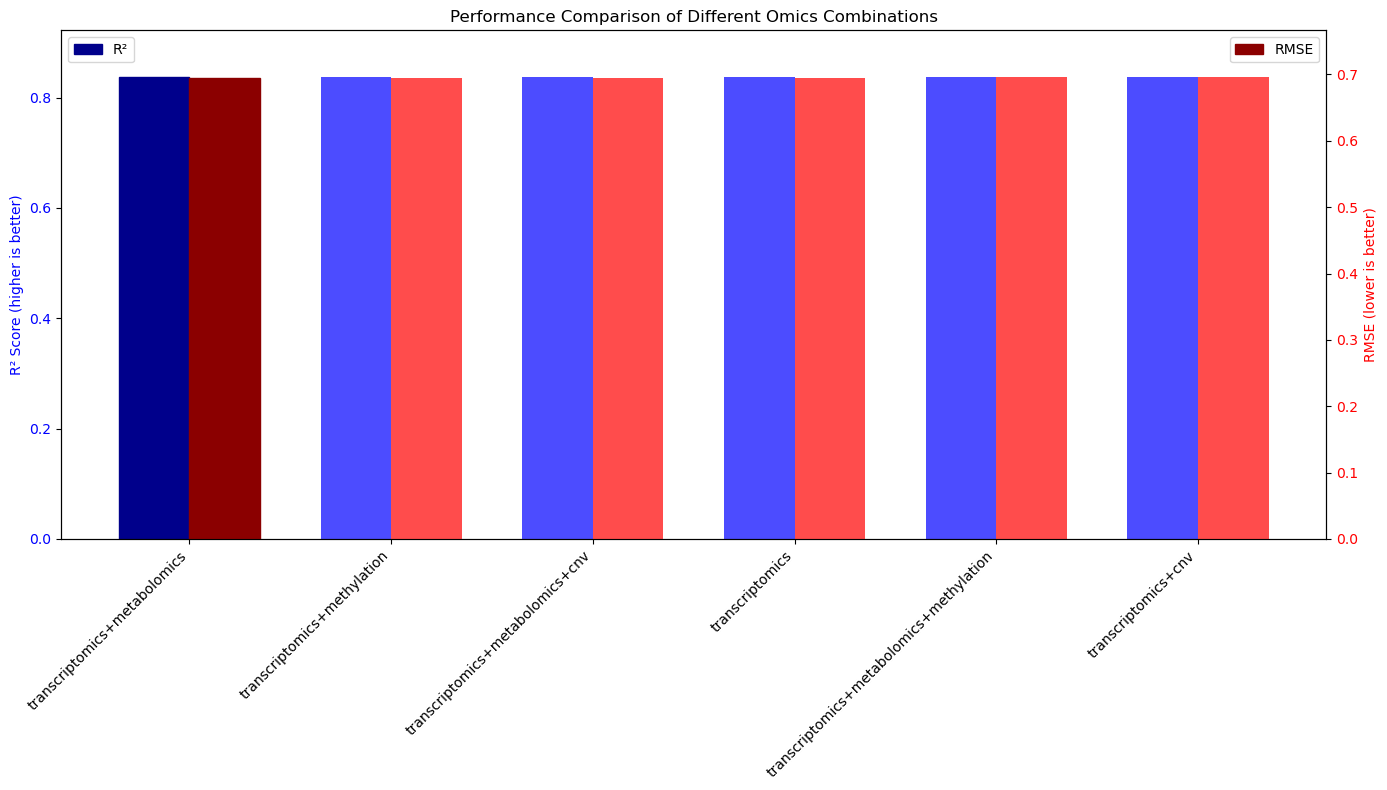

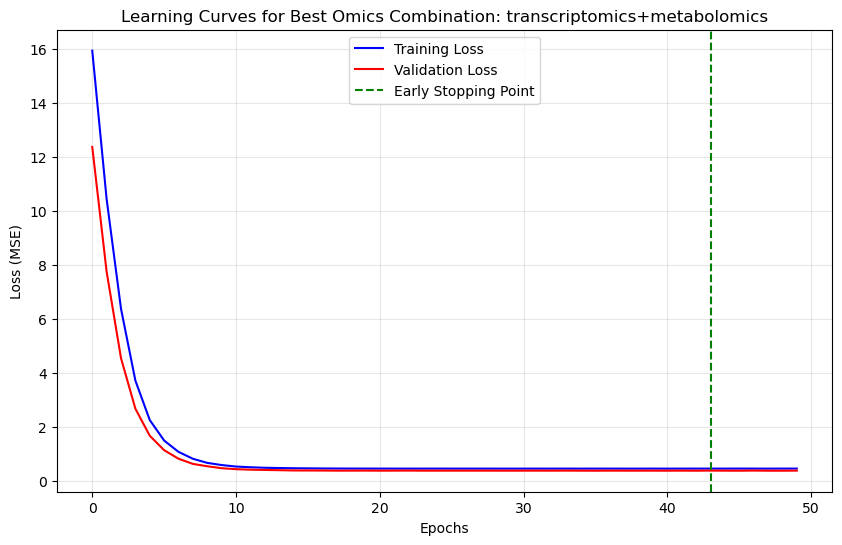

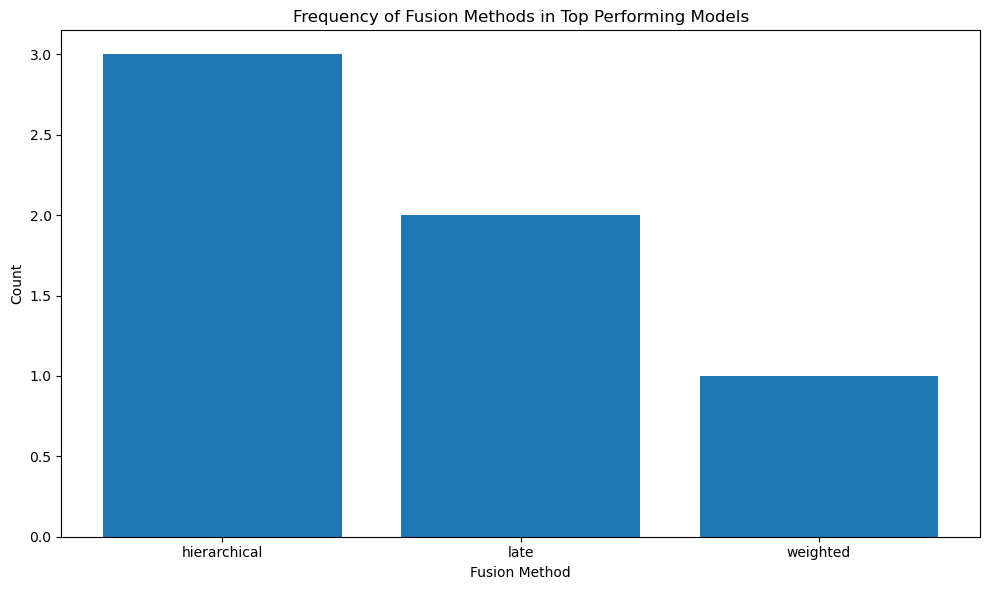


Best omics combination found: transcriptomics+metabolomics
Best R^2 score: 0.8380
Best model's hyperparameters saved successfully.


In [11]:
# All omics list
all_omics_types = ["methylation", "metabolomics", "transcriptomics", "cnv"]

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Run the progressive selection process
all_results, best_omics_set, progress_df = progressive_omics_selection(
    all_omics_types, datasets, n_trials=20, device=device
)

# Summarise the results
summary = summarise_results(all_results, best_omics_set)

# Save the progress dataframe
progress_df.to_csv(RESULT_PATH / "progressive_selection_results.csv", index=False)

# Print the best combination
print(f"\nBest omics combination found: {'+'.join(best_omics_set)}")
print(f"Best R^2 score: {all_results[tuple(best_omics_set)]['R2']:.4f}")


# Save the best model's hyperparameters
if "Hyperparameters" in all_results[tuple(best_omics_set)]:
    best_params = all_results[tuple(best_omics_set)]["Hyperparameters"]
    best_params_df = pd.DataFrame([best_params])
    best_params_df.to_csv(RESULT_PATH / "best_model_hyperparameters.csv", index=False)
    print("Best model's hyperparameters saved successfully.")
else:
    print("Error: 'Hyperparameters' key is missing for the best omics set.")
    best_params = {}
    print("Skipping saving hyperparameters due to missing data.")

# best_omics_set, best_params

# Results Transformer Models <a id="results-transformer"></a>

## Observations
Although gated fusion method gave the best R^2 score, cross-attention was the most frequently occuring fusion method in top performing models. Perhaps for future work, after cross-validation, dealing with outliers, and especially when the data amount grows, the cross-attention method could be the better performing one.

# Feature Analysis <a id="feature-analysis"></a>

NOTE: this part is also in the EMBL_transformer_best_model.ipynb

Look at best predicting proteomic features.


Analysing feature-level performance...

--------------------------------------------------------------------------------
Analysing feature-level performance for best model: ['transcriptomics', 'metabolomics']
--------------------------------------------------------------------------------


/home/jantine/miniconda3/envs/transformer_multiomics/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



Top 10 best predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
2140,LGALS1,-0.005032,2.856117,2.259318,0.837222,3.642375e-10
2087,KRT7,-0.006321,3.698985,3.208391,0.748225,2.374843e-07
1015,DDAH2,-0.010262,1.038499,0.843947,0.017302,9.214145e-01
3924,SHOC2,-0.014813,0.436888,0.352677,-0.145907,4.029648e-01
3105,PLIN3,-0.014972,1.413151,1.183682,0.427503,1.042000e-02
1715,GTF2H1,-0.021532,0.570258,0.498752,0.253119,1.423479e-01
4266,TAF6,-0.022089,0.370438,0.295200,0.018859,9.143683e-01
2784,NT5E,-0.025775,1.860777,1.549365,0.167086,3.373763e-01
2083,KRT19,-0.035755,3.437304,2.945389,0.593015,1.739550e-04
941,CTSB,-0.039124,1.584320,1.436534,0.358065,3.468627e-02



Bottom 10 worst predicted features:


,Feature,R2,RMSE,MAE,Correlation,P_value
3361,PTBP1,-11.333827,1.022630,0.979989,-0.358373,0.034519
4046,SNRPB2,-11.420307,0.911456,0.874036,0.174351,0.316482
1837,HNRNPM,-11.498786,1.120271,1.074171,-0.509009,0.001792
3901,SF3B6,-11.665883,0.979938,0.940486,0.087902,0.615582
3897,SF3B2,-12.573239,0.957739,0.921367,-0.488209,0.002926
1824,HNRNPA2B1,-13.005047,1.462944,1.409380,-0.485560,0.003108
1827,HNRNPC,-14.694257,1.318280,1.275348,-0.195942,0.259284
3172,POLR2L,-16.219000,0.933640,0.906120,-0.011045,0.949790
4051,SNRPE,-18.112999,0.932822,0.907622,-0.575476,0.000298
4050,SNRPD3,-21.346603,1.198592,1.171373,-0.157391,0.366543


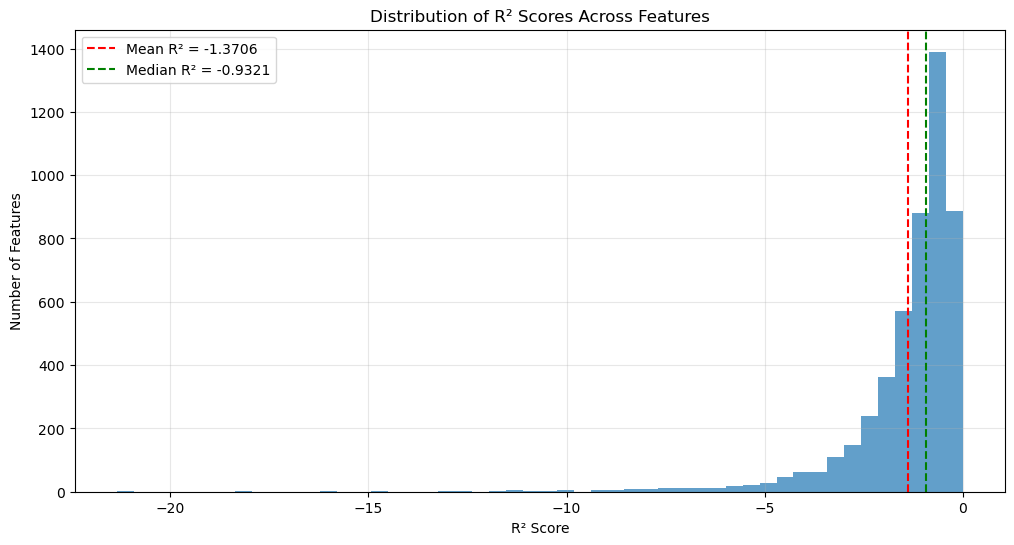

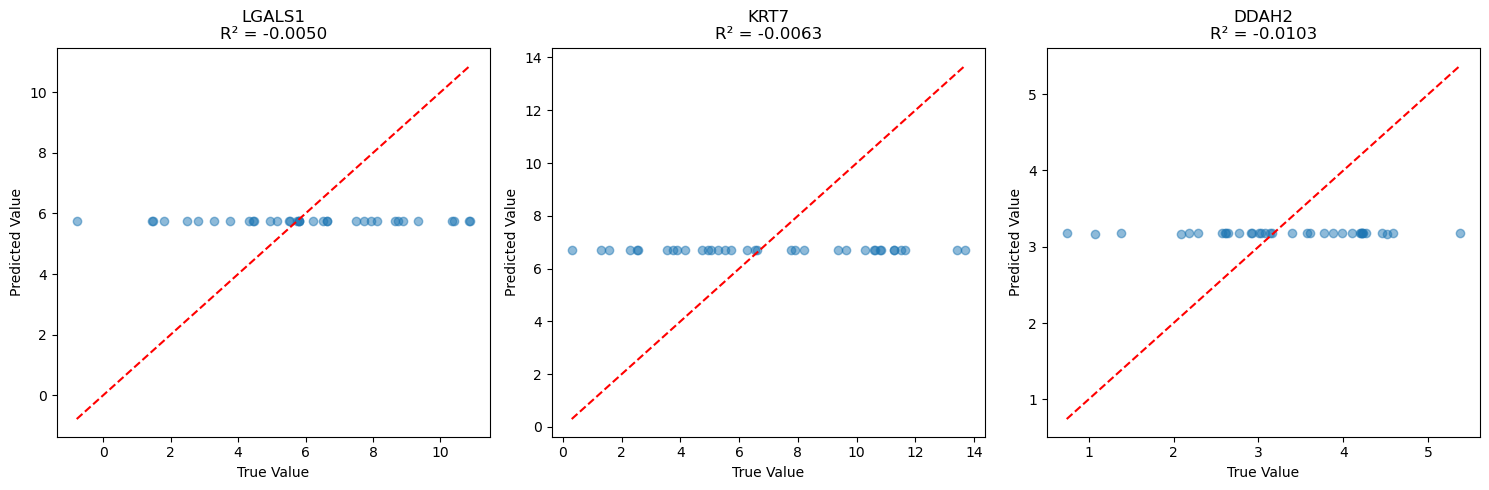

In [12]:
# Feature Analysis
print("\nAnalysing feature-level performance...")
feature_performance = analyse_feature_level_performance(best_omics_set, best_params, datasets, device)

# Best Predicting Protein Features <a id="results-feature-analysis"></a>

The results that the best predicting proteomic features actually have very low R^2 values, which indicates weak prediction performance and not a lot of variability is explained. The correlation values between the predicted and actual values >0.5 with significant p-values, so the model seems to capture some meaningful relationship between input omics data and protein expression, but not strongly. 


The disconnect between the correlation values and the very low R^2 values suggests that while the model is capturing some general trends in protein expression (hence the correlations), it's not accurately predicting the exact values (hence the poor R^2 values). This could be due to scaling issues in the predictions or systematic biases that the model hasn't learned to correct.


The RMSE values are consistently higher than MAE, suggesting some (larger) errors in the predictions. This because RMSE is more sensitive to outliers (quadratic penalty).